In [22]:
import random

from minigrid.core.grid import Grid
from minigrid.core.world_object import *
from minigrid.minigrid_env import MiniGridEnv
from minigrid.core.mission import MissionSpace
import numpy as np


def maze_backtrack(start_x, start_y, x_end, y_end, grid, destination):
    seen = set([(start_x, start_y)])
    stack = [((start_x, start_y), [(start_x, start_y)])]

    safe_path = []

    while stack:
        (x, y), current_path = stack.pop()
        
        if (x, y) == destination:
            safe_path = current_path
            break
            
        neighbors = [(x + 1, y), (x, y + 1), (x - 1, y), (x, y - 1)]
        random.shuffle(neighbors)
        
        for nx, ny in neighbors:
            # Jetzt darf er sich in der ganzen Box frei bewegen
            if start_x <= nx <= x_end and start_y <= ny <= y_end:
                if (nx, ny) not in seen:
                    seen.add((nx, ny))
                    stack.append(((nx, ny), current_path + [(nx, ny)]))
                
    # Pfad freiräumen (Bulldozer-Modus!)
    for x, y in safe_path:
        # GANZ WICHTIG: Den Schlüssel (destination) nicht plattmachen!
        if (x, y) != destination:
            grid[x, y] = "."
       

class Room:

    def generate():
        pass

class BasicRoom(Room):

    def __init__(self):

        self.room_string = """#######
        #.....#
        #.....+
        #.....#
        #######
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
      
        random_row = random.randint(1, grid.shape[0] - 2)
        random_col = random.randint(1, grid.shape[1] - 2)
        grid[random_row, random_col] = "A"
        return grid


class KeyRoom(Room): 
    def __init__(self):

        self.room_string = """
        #######
        #.....#
        #.....#
        +.....L
        #.....#
        #.....#
        #######
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(3, 4)
        agent_y = random.randint(1,2)
        
        key_x = random.choice([1,5])
        key_y = random.randint(1,5)

        grid[agent_x, agent_y] = "A"
        grid[key_x, key_y] = "K"

        return grid



class LockedIn(Room): 
    def __init__(self):

        self.room_string = """
        #########################################
        #.....#..........................#......#
        #.....D..........................#......#
        #.....#..........................##+##+##
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #LLLLL#..........................##+##+##
        #.....#..........................#......#
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #.....#..........................#......#
        #########################################
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(1, 2)
        grid[agent_x, random.randint(1,4)] = "A"

        lava_gap_x = [4,6,8]
        lava_gap_y = [random.randint(1,5),random.randint(1,5),random.randint(1,5)]
        grid[lava_gap_x, lava_gap_y] = "."
        random_key_x, random_key_y = random.randint(9,10), random.randint(1,5)
        grid[random_key_x, random_key_y] = "K"
     
        random_obstacles_y = np.random.randint(8, 32 , (130))
        random_obstacles_x = np.random.randint(1,10, (130))
        grid[random_obstacles_x, random_obstacles_y] = "#"

        random_key_maze_y = random.randint(12, 30)
        random_key_maze_x = random.randint(1,10)
        
        random_door_x = random.randint(2, 10)
        door_y = 33

        grid[random_door_x, door_y] = "D"
        maze_backtrack(2, 7, 10, 32, grid, destination=(random_key_maze_x, random_key_maze_y))
        maze_backtrack(random_key_maze_x, random_key_maze_y, random_door_x, door_y -1 , grid, destination=(random_door_x, door_y -1))
        grid[random_key_maze_x, random_key_maze_y] = "K"
        
        goal_x = random.choice([1,2,4,5,7,8,9,10])
        goal_y = random.randint(34,39)
        
        grid[goal_x, goal_y] = "G"
        return grid


class Dungeon(MiniGridEnv):

    def __init__(self, num_rooms):
        super().__init__(
            mission_space=MissionSpace(mission_func=lambda:"Goal"),
            render_mode="rgb_array",
            height=10,
            width=10
        ) 

        self.room_choices = [BasicRoom(), KeyRoom()]
        self.num_rooms = num_rooms
    
    def _gen_grid(self,_,__):

        '''grid = np.full((300,300), ".")
        curr_x, curr_y = 50, 50

        for _ in range(self.num_rooms):
            room_obj = random.choice(self.room_choices)
            room_data = room_obj.generate()
            h, w = room_data.shape

            grid[curr_y : curr_y + h, curr_x : curr_x + w] = room_data
           
            curr_x += (w - 1)


            
        rows, cols = np.where(grid != ".")
        min_row, max_row = np.min(rows), np.max(rows)
        min_col, max_col = np.min(cols), np.max(cols)
        grid = grid[min_row : max_row + 1, min_col : max_col + 1]'''

        grid = LockedIn().generate()
        flip = random.randint(0,3)
        for _ in range(flip):
            grid = np.rot90(grid)
        self.height, self.width = grid.shape
        self.grid = Grid(self.width, self.height)

        for y, row in enumerate(grid):
            for x, tile in enumerate(row):
                if tile == ".":
                    continue
                elif tile == "#":
                    self.grid.set(x,y, Wall())
                elif tile == "+":
                    self.grid.set(x,y, Door(color="red"))
                elif tile == "D":
                    self.grid.set(x, y, Door(color="blue", is_locked=True))
                elif tile == "K":
                    self.grid.set(x, y, Key(color="blue"))

                elif tile == "L":
                    self.grid.set(x,y, Lava())

                elif tile == "A":
                    self.agent_pos = (x, y)
                    self.agent_dir = random.choice([0,1,2,3])
                    self.grid.set(x, y, None)
                elif tile == "G":
                    self.grid.set(x,y, Goal())
                else:
                    continue                   

In [23]:
env = Dungeon(4)
_ = env.reset()

In [ ]:
from minigrid.envs.distshift import DistShiftEnv



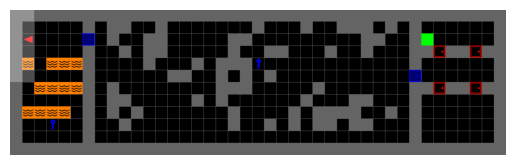

In [24]:
import matplotlib.pyplot as plt

frame = env.render()

plt.imshow(frame)
plt.axis('off') 
plt.show()

In [1]:
from envs.lava_maze import lava_0

/home/felix/miniconda3/envs/RL/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


cuda


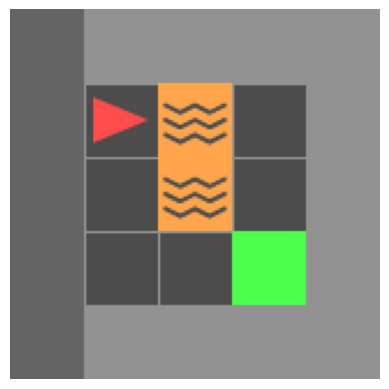

In [2]:
import matplotlib.pyplot as plt
env = lava_0()
env.reset()

frame = env.render()

plt.imshow(frame)
plt.axis('off') 
plt.show()

In [3]:
o,r,te,tr, info = env.step(action=1)

In [4]:
info

{'success': False}